# Eyewitness Message

---

## A. Original description

### A.1. Disaster-related data collection:

First, we collect Twitter data related to four different types of natural disasters. Specifically, several months of data about earthquakes, floods, wildfires, hurricanes are collected and used in this work

We then retrieved two data samples from our corpus.
- Our first sample is used for an initial manual analysis and includes data from three natural disasters types: earthquake, hurricane, and floods.
- Our second sample is used for crowdsourced annotation and includes data on four natural disaster types: earthquake, hurricane, floods, and wildfire. Data collection details are described in the next section.

### A.2. First data sample:

Taken from the collected data for three disaster types

#### Task 1: `Identify tweet source`:

This task aims to determine the source of a given tweet i.e., whether it is posted by an eyewitness or not, using only the message content. For this purpose, we consider the following three categories for the analysis:
- **Eyewitness**: if the message is posted by an eyewitness
- **Non-eyewitness**: if the message is posted by anyone else other than an eyewitness
- **Don’t know**: if it is not possible to determine which of the above two categories

#### Task 2: `Identify eyewitness type`
Only considers `eyewitness` tweet from Task 1,
- **direct eyewitness**, 
- **indirect eyewitness**. 
- **vulnerable eyewitness** people were anticipating a disaster and were present in the region for which disaster warnings were issued.

#### Reference

Kiran Zahra, Muhammad Imran, Frank Ostermann. Automatic Identification of Eyewitness Messages on Twitter During Disasters. In the Journal of Information Processing & Management (IP&M), 2020.


## B. Overview

In [1]:
from pathlib import Path
import os
import uuid

import numpy as np
import pandas as pd

from dotenv import load_dotenv
load_dotenv()

datasets_path = Path(os.getenv("DATASETS_PATH")) / 'Eyewitness_Tweets/eyewitness_tweets_annotations_14k_public'

### B.1. First sample

In [2]:
dataset_path_t1 = datasets_path / 'labeled_by_authors'

files_t1 = [
    'earthquakes_eyewitness_annotations_2000.tsv',
    'floods_eyewitness_annotations_2000.tsv',
    'hurricanes_eyewitness_annotations_2004.tsv',
]

#### Task 1

In [3]:
df_t1_earthquakes = pd.read_csv(dataset_path_t1 / files_t1[0], sep='\t')
df_t1_floods = pd.read_csv(dataset_path_t1 / files_t1[1], sep='\t')
df_t1_hurricanes = pd.read_csv(dataset_path_t1 / files_t1[2], sep='\t')

df_t1_earthquakes.head()

,text,label,source,created_at,lang,listed_count,verified,location,statuses_count,followers_count,favourites_count,time_zone,user_lang,friends_count,screen_name
0,#earthquake Magnitude 2.1 occurred 159km NE of...,non-eyewitness,"<a href=""http://www.didyoufeel.it/"" rel=""nofol...",Tue Aug 01 08:12:42 +0000 2017,en,7.0,f,Italia,92091.0,1248.0,1.0,Central America,en,1756.0,did_you_feel_it
1,Retweeted Earthquakes Tsunamis (@NewEarthquake...,non-eyewitness,"<a href=""http://www.facebook.com/twitter"" rel=...",Tue Aug 01 08:13:08 +0000 2017,en,287.0,f,Malaysia,100720.0,1680.0,13260.0,Kuala Lumpur,en,2486.0,LimAiYim
2,I always know I need to go shopping when I've ...,don't know,"<a href=""https://mobile.twitter.com"" rel=""nofo...",Tue Aug 01 08:13:15 +0000 2017,en,0.0,f,"Hollywood, California, USA..... planet earth",2206.0,89.0,959.0,NaN,en,85.0,3DennisCarlins
3,Update: M2.0 #earthquake (#sismo) strikes 1 km...,non-eyewitness,"<a href=""http://www.emsc-csem.org/"" rel=""nofol...",Tue Aug 01 08:13:48 +0000 2017,en,392.0,f,"BruyÃ¨res-Le-Chatel, France",98956.0,8970.0,1.0,Belgrade,fr,3.0,EMSC
4,ã€,non-eyewitness,"<a href=""http://twdesk.com/"" rel=""nofollow"">ã",Tue Aug 01 08:14:58 +0000 2017,en,54.0,f,With everyone,265090.0,4165.0,29.0,Irkutsk,ja,3800.0,from___japan


In [4]:
df_t1_floods.rename(columns={'lable': 'label'}, inplace=True)
df_t1_hurricanes.rename(columns={'Lable': 'label'}, inplace=True)

df_t1_earthquakes['event_type'] = 'earthquake'
df_t1_floods['event_type'] = 'flood'
df_t1_hurricanes['event_type'] = 'storm'

df_t1_earthquakes["meta"] = df_t1_earthquakes.apply(lambda row: { "file_name": files_t1[0]}, axis=1)
df_t1_floods["meta"] = df_t1_floods.apply(lambda row: { "file_name": files_t1[1]}, axis=1)
df_t1_hurricanes["meta"] = df_t1_hurricanes.apply(lambda row: { "file_name": files_t1[2]}, axis=1)

df_t1 = pd.concat([df_t1_earthquakes, df_t1_floods, df_t1_hurricanes], ignore_index=True)

df_t1 = df_t1[df_t1['lang'] == 'en']

df_t1.rename(columns={"label": "original_relevant_label"}, inplace=True)
df_t1 = df_t1[['text', 'event_type', 'created_at', 'original_relevant_label', 'meta']]

df_t1['tweet_id'] = df_t1.apply(lambda _: uuid.uuid4(), axis=1)
df_t1['dataset'] = 'eyewitness_messages_authors'

df_t1.head()

,text,event_type,created_at,original_relevant_label,meta,tweet_id,dataset
0,#earthquake Magnitude 2.1 occurred 159km NE of...,earthquake,Tue Aug 01 08:12:42 +0000 2017,non-eyewitness,{'file_name': 'earthquakes_eyewitness_annotati...,2c8b6fc3-05c0-406e-98dc-410c7d71b11c,eyewitness_messages_authors
1,Retweeted Earthquakes Tsunamis (@NewEarthquake...,earthquake,Tue Aug 01 08:13:08 +0000 2017,non-eyewitness,{'file_name': 'earthquakes_eyewitness_annotati...,9a8d0d83-bc3f-4b6b-be02-6022754abf6d,eyewitness_messages_authors
2,I always know I need to go shopping when I've ...,earthquake,Tue Aug 01 08:13:15 +0000 2017,don't know,{'file_name': 'earthquakes_eyewitness_annotati...,002adf15-6311-4a2b-a9a5-ce0c3b1dc20f,eyewitness_messages_authors
3,Update: M2.0 #earthquake (#sismo) strikes 1 km...,earthquake,Tue Aug 01 08:13:48 +0000 2017,non-eyewitness,{'file_name': 'earthquakes_eyewitness_annotati...,32bb1f81-fd58-465e-b80f-b8023d274ce6,eyewitness_messages_authors
4,ã€,earthquake,Tue Aug 01 08:14:58 +0000 2017,non-eyewitness,{'file_name': 'earthquakes_eyewitness_annotati...,12e6611e-558b-4427-86d3-fc0e0254198b,eyewitness_messages_authors


### Task 2

In [5]:
dataset_path_t2 = datasets_path / 'labeled_by_crowdflower_paid_workers'

files_t2 = [
    'earthquakes_eyewitness_crowdflower_2000.tsv',
    'floods_eyewitness_crowdflower_2000.tsv',
    'forestfires_eyewitness_crowdflower_2000.tsv',
    'hurricanes_eyewitness_crowdflower_2000.tsv',
]

In [6]:
df_t2_earthquakes = pd.read_csv(dataset_path_t2 / files_t2[0], sep='\t')
df_t2_floods = pd.read_csv(dataset_path_t2 / files_t2[1], sep='\t')
df_t2_forestfires = pd.read_csv(dataset_path_t2 / files_t2[2], sep='\t')
df_t2_hurricanes = pd.read_csv(dataset_path_t2 / files_t2[3], sep='\t')

df_t2_earthquakes.head()

,_unit_id,_golden,_unit_state,_trusted_judgments,_last_judgment_at,please_choose_a_category:confidence,created_at,id_str,rownames,please_choose_a_category,text,Unnamed: 11,Unnamed: 12
0,1846692712,False,finalized,3,08/03/2018 20:23,0.6664,Mon May 14 22:49:14 +0000 2018,",996160536487358464,",79959,direct_eyewitness,"TheReformedCrow Nah, I'm gonna go with earthq...",NaN,NaN
1,1846692769,False,finalized,3,08/03/2018 20:46,1.0000,Tue May 15 02:19:00 +0000 2018,",996213327398289408,",99307,direct_eyewitness,I think we just had an earthquake,NaN,NaN
2,1846692882,False,finalized,3,08/03/2018 21:36,1.0000,Tue May 15 02:19:12 +0000 2018,",996213376370950144,",99629,direct_eyewitness,Uhh who else felt that earthquake tho,NaN,NaN
3,1846694004,False,finalized,3,08/03/2018 21:10,0.3580,Tue May 15 02:20:41 +0000 2018,",996213749903077376,",102406,direct_eyewitness,Bay area just had a nice size earthquake,NaN,NaN
4,1846693321,False,finalized,3,08/03/2018 20:37,1.0000,Tue May 15 02:19:43 +0000 2018,",996213508357279744,",100701,direct_eyewitness,Thought my dad was farting...turns out it was ...,NaN,NaN


In [7]:
df_t2_earthquakes['event_type'] = 'earthquake'
df_t2_floods['event_type'] = 'flood'
df_t2_forestfires['event_type'] = 'wildfire'
df_t2_hurricanes['event_type'] = 'storm'

df_t2_earthquakes["meta"] = df_t2_earthquakes.apply(lambda row: { "file_name": files_t2[0]}, axis=1)
df_t2_floods["meta"] = df_t2_floods.apply(lambda row: { "file_name": files_t2[1]}, axis=1)
df_t2_forestfires["meta"] = df_t2_forestfires.apply(lambda row: { "file_name": files_t2[2]}, axis=1)
df_t2_hurricanes["meta"] = df_t2_hurricanes.apply(lambda row: { "file_name": files_t2[3]}, axis=1)

df_t2 = pd.concat([df_t2_earthquakes, df_t2_floods, df_t2_forestfires, df_t2_hurricanes], ignore_index=True)

df_t2 = df_t2[df_t2['_golden'] == False]

df_t2 = df_t2[['id_str', 'text', 'event_type', 'created_at', 'please_choose_a_category', 'meta']]
df_t2.rename(columns={'id_str':'tweet_id', 'please_choose_a_category': 'original_relevant_label'}, inplace=True)

import re
df_t2['tweet_id'] = df_t2['tweet_id'].str.extract(r'(\d+)', expand=False).astype(int)
df_t2['dataset'] = 'eyewitness_messages_crowdflower'


df_t2.head()

,tweet_id,text,event_type,created_at,original_relevant_label,meta,dataset
0,996160536487358464,"TheReformedCrow Nah, I'm gonna go with earthq...",earthquake,Mon May 14 22:49:14 +0000 2018,direct_eyewitness,{'file_name': 'earthquakes_eyewitness_crowdflo...,eyewitness_messages_crowdflower
1,996213327398289408,I think we just had an earthquake,earthquake,Tue May 15 02:19:00 +0000 2018,direct_eyewitness,{'file_name': 'earthquakes_eyewitness_crowdflo...,eyewitness_messages_crowdflower
2,996213376370950144,Uhh who else felt that earthquake tho,earthquake,Tue May 15 02:19:12 +0000 2018,direct_eyewitness,{'file_name': 'earthquakes_eyewitness_crowdflo...,eyewitness_messages_crowdflower
3,996213749903077376,Bay area just had a nice size earthquake,earthquake,Tue May 15 02:20:41 +0000 2018,direct_eyewitness,{'file_name': 'earthquakes_eyewitness_crowdflo...,eyewitness_messages_crowdflower
4,996213508357279744,Thought my dad was farting...turns out it was ...,earthquake,Tue May 15 02:19:43 +0000 2018,direct_eyewitness,{'file_name': 'earthquakes_eyewitness_crowdflo...,eyewitness_messages_crowdflower


### Combine

In [8]:
df = pd.concat([df_t1, df_t2], ignore_index=True)

df.rename(columns={'text': 'tweet_text'}, inplace=True)
df['dataset'] = 'eyewitness_messages'
df['relevant'] = True
df['humanitarian_label'] = np.nan
df['event_name'] = np.nan
df["original_humanitarian_label"] = np.nan
df['year'] = df['created_at'].apply(lambda x: int(x.split()[-1]))

df.drop(columns=['created_at'], inplace=True)

df.head()

,tweet_text,event_type,original_relevant_label,meta,tweet_id,dataset,relevant,humanitarian_label,event_name,original_humanitarian_label,year
0,#earthquake Magnitude 2.1 occurred 159km NE of...,earthquake,non-eyewitness,{'file_name': 'earthquakes_eyewitness_annotati...,2c8b6fc3-05c0-406e-98dc-410c7d71b11c,eyewitness_messages,True,NaN,NaN,NaN,2017
1,Retweeted Earthquakes Tsunamis (@NewEarthquake...,earthquake,non-eyewitness,{'file_name': 'earthquakes_eyewitness_annotati...,9a8d0d83-bc3f-4b6b-be02-6022754abf6d,eyewitness_messages,True,NaN,NaN,NaN,2017
2,I always know I need to go shopping when I've ...,earthquake,don't know,{'file_name': 'earthquakes_eyewitness_annotati...,002adf15-6311-4a2b-a9a5-ce0c3b1dc20f,eyewitness_messages,True,NaN,NaN,NaN,2017
3,Update: M2.0 #earthquake (#sismo) strikes 1 km...,earthquake,non-eyewitness,{'file_name': 'earthquakes_eyewitness_annotati...,32bb1f81-fd58-465e-b80f-b8023d274ce6,eyewitness_messages,True,NaN,NaN,NaN,2017
4,ã€,earthquake,non-eyewitness,{'file_name': 'earthquakes_eyewitness_annotati...,12e6611e-558b-4427-86d3-fc0e0254198b,eyewitness_messages,True,NaN,NaN,NaN,2017


In [9]:
df.drop_duplicates(subset=['tweet_id'], inplace=True)
df.dropna(subset=['tweet_text'], inplace=True)
df.drop_duplicates(subset=['tweet_text'], inplace=True)

In [10]:
import csv
df.to_csv('datasets/eyewitness_messages.csv', index=False, quoting=csv.QUOTE_ALL)

## Verify

<Axes: xlabel='relevant'>

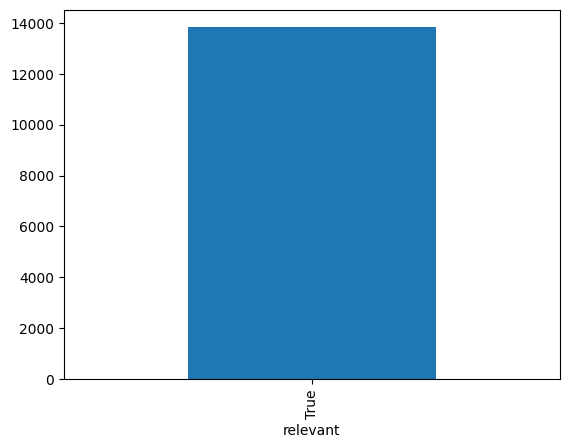

In [11]:
df['relevant'].value_counts().plot(kind='bar')

<Axes: xlabel='event_type'>

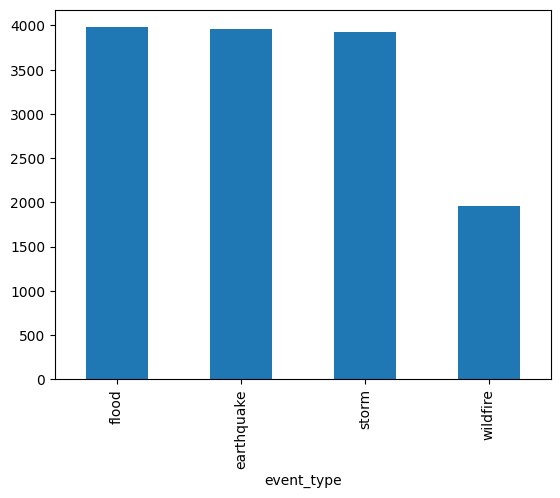

In [12]:
df['event_type'].value_counts().plot(kind='bar')